# Predicting Smartphone Addiction Severity in Teenagers
## A Comparative Study: Traditional Machine Learning vs. Deep Learning

**Author:** Nick-Lemy Kayiranga  
**Course:** Introduction to Machine Learning  
**Dataset:** Teen Phone Addiction Dataset (Kaggle)  
**GitHub:** https://github.com/Nick-Lemy/teen_phone_addiction-classification
**Video:** https://vimeo.com/1167013525

---

Smartphone addiction among adolescents is a growing public health concern, associated with anxiety, depression, poor sleep, and declining academic performance. This notebook builds and compares **traditional machine learning (Scikit-learn)** and **deep learning (TensorFlow Sequential and Functional APIs)** models to predict a teenager's addiction severity tier (Low / Medium / High) from behavioral, psychological, and demographic features.

Experiments are conducted iteratively; each one motivated by the limitations observed in the previous; culminating in a dual-branch Functional API architecture and a TabNet model.


---
## 1. Imports and Setup

All dependencies are installed and imported here. The random seed is fixed at 42 across NumPy, TensorFlow, and all Scikit-learn models to ensure full reproducibility across runs.

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow xgboost imbalanced-learn pytorch-tabnet --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve, auc)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import torch
from pytorch_tabnet.tab_model import TabNetClassifier

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print("All libraries loaded. Seeds fixed at 42.")

TensorFlow 2.19.0 | NumPy 2.0.2
All libraries loaded. Seeds fixed at 42.


---
## 2. Data Loading and Exploration

The dataset contains **3,000 records** of teenagers aged 13–19 with 25 features covering demographics, phone usage behaviour, and mental health indicators. The target variable `Addiction_Level` is a continuous score from 0 to 10.

We perform a structural audit first: checking data types, missing values, and the overall shape before any transformation.

In [4]:
df = pd.read_csv('/kaggle/input/datasets/sumedh1507/teen-phone-addiction/teen_phone_addiction_dataset.csv')
# If running locally: df = pd.read_csv('teen_phone_addiction_dataset.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (3000, 25)
Columns: ['ID', 'Name', 'Age', 'Gender', 'Location', 'School_Grade', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours', 'Addiction_Level']


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [5]:
# Structural audit: data types and missing values
audit = pd.DataFrame({
    'dtype': df.dtypes,
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
print(audit)
print("\nDescriptive statistics:")
df.describe().round(2)

                          dtype  missing  missing_%
ID                        int64        0        0.0
Name                     object        0        0.0
Age                       int64        0        0.0
Gender                   object        0        0.0
Location                 object        0        0.0
School_Grade             object        0        0.0
Daily_Usage_Hours       float64        0        0.0
Sleep_Hours             float64        0        0.0
Academic_Performance      int64        0        0.0
Social_Interactions       int64        0        0.0
Exercise_Hours          float64        0        0.0
Anxiety_Level             int64        0        0.0
Depression_Level          int64        0        0.0
Self_Esteem               int64        0        0.0
Parental_Control          int64        0        0.0
Screen_Time_Before_Bed  float64        0        0.0
Phone_Checks_Per_Day      int64        0        0.0
Apps_Used_Daily           int64        0        0.0
Time_on_Soci

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,1500.50,15.97,5.02,6.49,74.95,5.10,1.04,5.59,5.46,5.55,0.51,1.01,83.09,12.61,2.50,1.53,1.02,5.46,6.02,8.88
std,866.17,1.99,1.96,1.49,14.68,3.14,0.73,2.89,2.87,2.86,0.50,0.49,37.75,4.61,0.99,0.93,0.65,2.86,2.01,1.61
min,1.00,13.00,0.00,3.00,50.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,20.00,5.00,0.00,0.00,0.00,1.00,0.00,1.00
25%,750.75,14.00,3.70,5.50,62.00,2.00,0.50,3.00,3.00,3.00,0.00,0.70,51.00,9.00,1.80,0.80,0.50,3.00,4.70,8.00
50%,1500.50,16.00,5.00,6.50,75.00,5.00,1.00,6.00,5.00,6.00,1.00,1.00,82.00,13.00,2.50,1.50,1.00,5.00,6.00,10.00
75%,2250.25,18.00,6.40,7.50,88.00,8.00,1.50,8.00,8.00,8.00,1.00,1.40,115.25,17.00,3.20,2.20,1.50,8.00,7.40,10.00
max,3000.00,19.00,11.50,10.00,100.00,10.00,4.00,10.00,10.00,10.00,1.00,2.60,150.00,20.00,5.00,4.00,3.00,10.00,14.00,10.00


---
## 3. Exploratory Data Analysis

Before modelling, we examine the target distribution, feature correlations, and relationships between mental health indicators and addiction severity.

Key findings from the EDA that will inform preprocessing decisions:
- `Addiction_Level` is heavily **right-skewed**, with a mean of 8.88 and a large concentration at 10. This has direct implications for how we bin the target.
- `Daily_Usage_Hours` is the strongest linear predictor (r = 0.60), followed by `Apps_Used_Daily` (r = 0.32) and `Time_on_Social_Media` (r = 0.31).
- `Sleep_Hours` shows a meaningful negative correlation (r = −0.22), supporting the engineered `Screen_to_Sleep_Ratio` feature.
- Mental health indicators (Anxiety, Depression, Self-Esteem) show near-zero individual correlations with the target, which motivates their composite treatment via `Mental_Health_Index`.
- Gender has virtually no effect on mean addiction level across all three groups.

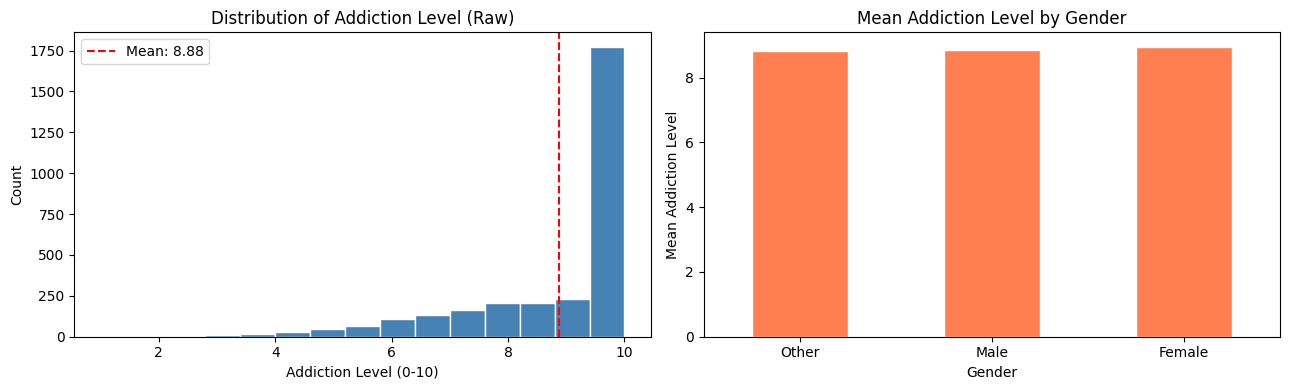

Figure 1: The distribution is right-skewed with a mean of 8.88, indicating most teenagers score high on addiction.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Addiction_Level'], bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(df['Addiction_Level'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["Addiction_Level"].mean():.2f}')
axes[0].set_title('Distribution of Addiction Level (Raw)')
axes[0].set_xlabel('Addiction Level (0-10)')
axes[0].set_ylabel('Count')
axes[0].legend()

df.groupby('Gender')['Addiction_Level'].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Mean Addiction Level by Gender')
axes[1].set_ylabel('Mean Addiction Level')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1: The distribution is right-skewed with a mean of 8.88, indicating most teenagers score high on addiction.")

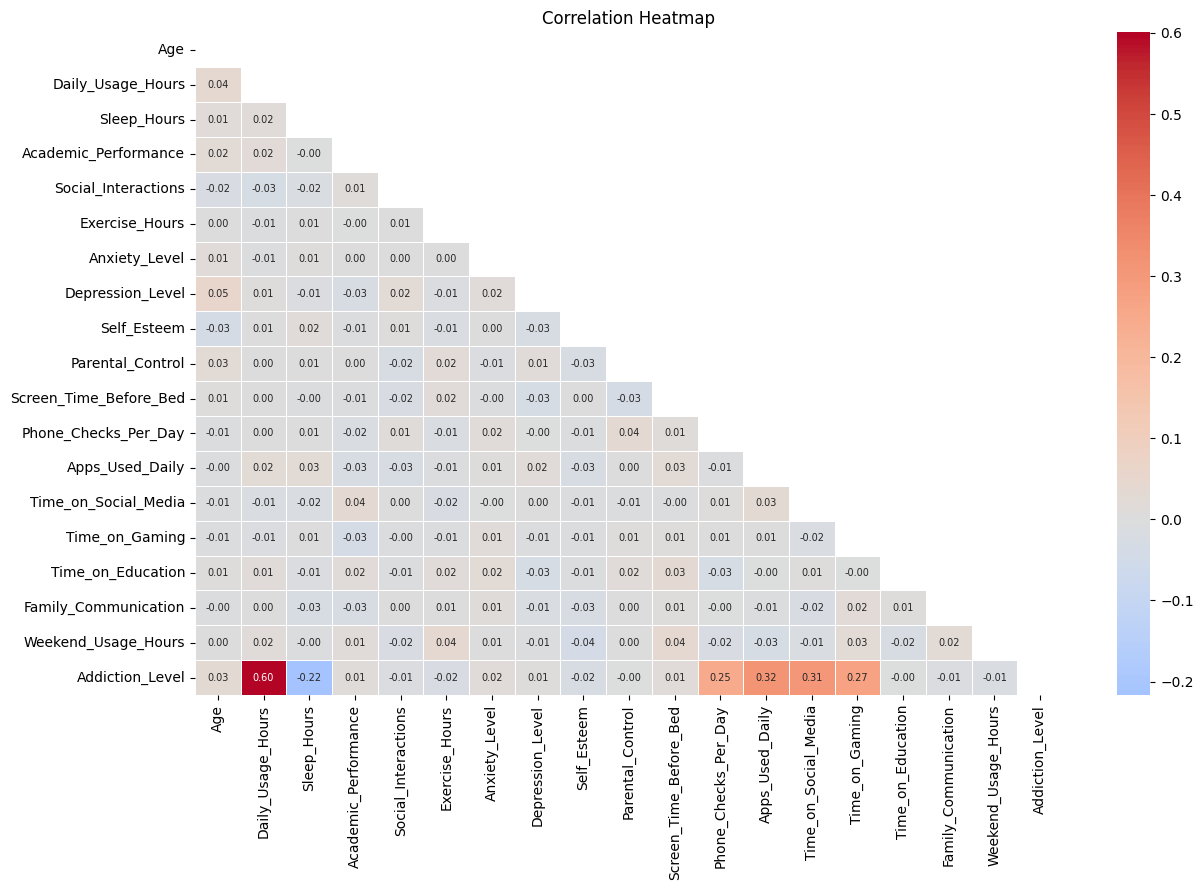

Top correlations with Addiction_Level:
Daily_Usage_Hours         0.600771
Apps_Used_Daily           0.319287
Time_on_Social_Media      0.306578
Time_on_Gaming            0.273060
Phone_Checks_Per_Day      0.246342
Age                       0.031306
Anxiety_Level             0.016005
Screen_Time_Before_Bed    0.013784
Academic_Performance      0.012264
Depression_Level          0.008491
Time_on_Education        -0.000586
Parental_Control         -0.001016
Family_Communication     -0.010482
Social_Interactions      -0.010631
Weekend_Usage_Hours      -0.013049
Exercise_Hours           -0.021015
Self_Esteem              -0.022292
Sleep_Hours              -0.216681
Name: Addiction_Level, dtype: float64


In [7]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['ID']).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(13, 9))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('fig2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top correlations with Addiction_Level:")
print(corr['Addiction_Level'].sort_values(ascending=False).drop('Addiction_Level'))

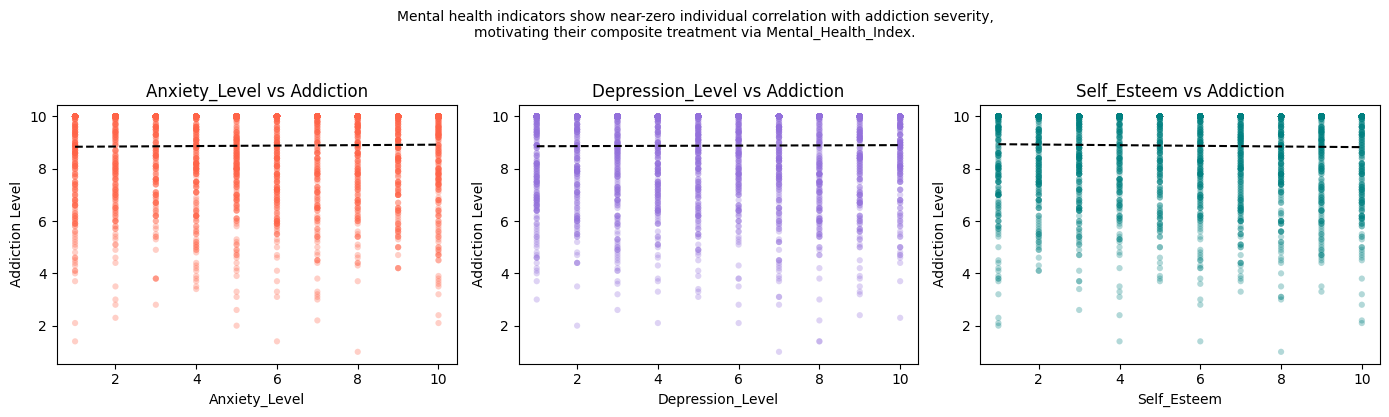

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat, col in zip(axes,
                         ['Anxiety_Level', 'Depression_Level', 'Self_Esteem'],
                         ['tomato', 'mediumpurple', 'teal']):
    ax.scatter(df[feat], df['Addiction_Level'], alpha=0.3, color=col, edgecolors='none', s=20)
    z = np.polyfit(df[feat], df['Addiction_Level'], 1)
    ax.plot(sorted(df[feat]), np.poly1d(z)(sorted(df[feat])), 'k--', lw=1.5)
    ax.set_xlabel(feat); ax.set_ylabel('Addiction Level')
    ax.set_title(f'{feat} vs Addiction')

plt.suptitle('Mental health indicators show near-zero individual correlation with addiction severity,\nmotivating their composite treatment via Mental_Health_Index.', fontsize=10, y=1.03)
plt.tight_layout()
plt.savefig('fig3_mental_health.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Preprocessing and Feature Engineering

### 4.1 Target Encoding

We bin `Addiction_Level` into three tiers using fixed score thresholds. The quantile approach was tested first but failed due to the heavy concentration of values at 10. Fixed thresholds produce interpretable, stable class boundaries:
- **Low (0):** score 0–4
- **Medium (1):** score 5–7
- **High (2):** score 8–10

This produces a severely imbalanced distribution (Low=42, Medium=404, High=2554), which is addressed through SMOTE applied exclusively on the training set.

### 4.2 Feature Engineering

Five composite features are engineered from domain knowledge:

| Feature | Formula | Rationale |
|---|---|---|
| `Mental_Health_Index` | Anxiety + Depression - Self_Esteem | Captures composite psychological risk not visible in individual features |
| `Screen_to_Sleep_Ratio` | Daily_Usage / Sleep_Hours | Quantifies sleep displacement by screen time |
| `Night_Screen_Risk` | Screen_Before_Bed x Phone_Checks | Proxy for compulsive nocturnal phone use |
| `Passive_Use_Flag` | 1 if Browsing or Social Media | Distinguishes passive from active consumption |
| `Social_Engagement_Score` | Social_Interactions + Family_Communication | Measures offline social support network |

### 4.3 Column Handling

`ID`, `Name`, and `Location` are dropped. `ID` and `Name` are unique identifiers with no predictive value. `Location` is a high-cardinality free-text field representing cities; it is not meaningful for this problem and one-hot encoding it would explode the feature space to over 2,700 columns, introducing noise and harming model performance.

Remaining categorical columns (`Gender`, `School_Grade`, `Phone_Usage_Purpose`) are label-encoded.

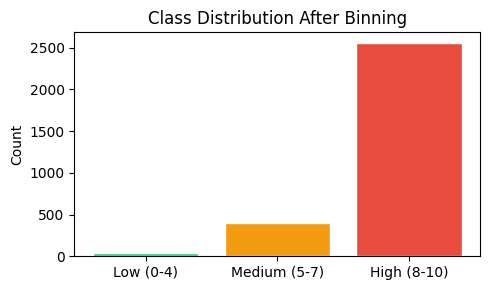

Low: 42 | Medium: 404 | High: 2554
Severe class imbalance confirmed. SMOTE will be applied on training data only.


In [9]:
# Target binning
df['Addiction_Class'] = pd.cut(df['Addiction_Level'], bins=[-1, 4, 7, 10],
                                labels=[0, 1, 2]).astype(int)

counts = df['Addiction_Class'].value_counts().sort_index()
plt.figure(figsize=(5, 3))
plt.bar(['Low (0-4)', 'Medium (5-7)', 'High (8-10)'], counts.values,
        color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
plt.title('Class Distribution After Binning')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('fig4_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Low: {counts[0]} | Medium: {counts[1]} | High: {counts[2]}")
print("Severe class imbalance confirmed. SMOTE will be applied on training data only.")

In [10]:
# Feature engineering
df['Mental_Health_Index']     = df['Anxiety_Level'] + df['Depression_Level'] - df['Self_Esteem']
df['Screen_to_Sleep_Ratio']   = df['Daily_Usage_Hours'] / (df['Sleep_Hours'] + 1e-5)
df['Night_Screen_Risk']       = df['Screen_Time_Before_Bed'] * df['Phone_Checks_Per_Day']
df['Passive_Use_Flag']        = df['Phone_Usage_Purpose'].isin(['Browsing', 'Social Media']).astype(int)
df['Social_Engagement_Score'] = df['Social_Interactions'] + df['Family_Communication']

# Drop non-predictive columns — Location excluded due to high cardinality
df_model = df.drop(columns=['ID', 'Name', 'Location', 'Addiction_Level', 'Addiction_Class'])

# Label encode low-cardinality categoricals
for col in ['Gender', 'School_Grade', 'Phone_Usage_Purpose']:
    df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

X = df_model.copy()
y = df['Addiction_Class'].values

print(f"Feature matrix: {X.shape} | Classes: {np.bincount(y)}")
print(f"Features: {list(X.columns)}")

Feature matrix: (3000, 26) | Classes: [  42  404 2554]
Features: ['Age', 'Gender', 'School_Grade', 'Daily_Usage_Hours', 'Sleep_Hours', 'Academic_Performance', 'Social_Interactions', 'Exercise_Hours', 'Anxiety_Level', 'Depression_Level', 'Self_Esteem', 'Parental_Control', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day', 'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Phone_Usage_Purpose', 'Family_Communication', 'Weekend_Usage_Hours', 'Mental_Health_Index', 'Screen_to_Sleep_Ratio', 'Night_Screen_Risk', 'Passive_Use_Flag', 'Social_Engagement_Score']


In [11]:
# Stratified train/test split preserves class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# Scale features — fit on train only to prevent leakage
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")
print(f"Test class distribution: {np.bincount(y_test)}")
print("Note: SMOTE will be applied per-experiment on training data only, never on test data.")

Train: (2400, 26) | Test: (600, 26)
Test class distribution: [  8  81 511]
Note: SMOTE will be applied per-experiment on training data only, never on test data.


---
## 5. tf.data Pipeline

The `tf.data` API provides an efficient, scalable input pipeline for TensorFlow models through batching, shuffling, and prefetching. Rather than feeding raw numpy arrays to `model.fit()`, this pipeline handles data loading asynchronously, improving GPU utilisation during training.

This pipeline is reused by all deep learning experiments in Sections 11–13.

In [12]:
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def make_dataset(X_arr, y_arr, shuffle=True):
    """Create a tf.data.Dataset with batching, shuffling, and prefetching.
    
    Args:
        X_arr: Feature array (numpy float32)
        y_arr: Label array (numpy int32)
        shuffle: Whether to shuffle before batching
    Returns:
        Prefetched, batched tf.data.Dataset
    """
    ds = tf.data.Dataset.from_tensor_slices(
        (X_arr.astype(np.float32), y_arr.astype(np.int32)))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_arr), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# These will be rebuilt per-experiment after SMOTE is applied
test_ds = make_dataset(X_test_sc, y_test, shuffle=False)

for xb, yb in test_ds.take(1):
    print(f"Batch features: {xb.shape} | Batch labels: {yb.shape} | dtype: {xb.dtype}")
print("tf.data pipeline ready.")

Batch features: (32, 26) | Batch labels: (32,) | dtype: <dtype: 'float32'>
tf.data pipeline ready.


2026-02-21 20:41:21.068569: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


---
## Shared Evaluation Utilities

The helper functions below standardise evaluation across all experiments, ensuring consistent metric reporting and enabling direct comparison in the results table.

In [13]:
results = []  # Accumulates all experiment results
CLASS_NAMES = ['Low', 'Medium', 'High']

def record_and_print(exp_num, name, y_true, y_pred, y_prob=None, cv_score=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    roc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro') if y_prob is not None else '-'
    results.append({
        'Exp': exp_num, 'Model': name,
        'Accuracy': round(acc, 4),
        'Macro F1': round(f1, 4),
        'ROC-AUC': round(roc, 4) if roc != '-' else '-',
        'CV Macro F1': cv_score if cv_score else '-'
    })
    print(f"\n--- Exp {exp_num}: {name} ---")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f}" +
          (f" | ROC-AUC: {roc:.4f}" if roc != '-' else ''))
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

def plot_curves(history, title, exp_num):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, label in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        ax.plot(history.history[metric], label='Train')
        ax.plot(history.history[f'val_{metric}'], label='Validation', linestyle='--')
        ax.set_title(f'{label} — {title}')
        ax.set_xlabel('Epoch'); ax.set_ylabel(label)
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'fig_curves_exp{exp_num}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Helper functions defined.")

Helper functions defined.


---
## 6. Experiment 1 - Logistic Regression (Baseline)

We start with Logistic Regression as the simplest possible classifier. It assumes a linear decision boundary and serves as the minimum performance threshold all subsequent models must beat.

Class weighting is applied to penalise misclassification of minority classes. No SMOTE yet — we want to observe the raw impact of class imbalance on a linear model before adding oversampling.

In [14]:
lr_base = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                              max_iter=1000, class_weight='balanced', random_state=SEED)
lr_base.fit(X_train_sc, y_train)
p1     = lr_base.predict(X_test_sc)
prob1  = lr_base.predict_proba(X_test_sc)
cv1    = cross_val_score(lr_base, X_train_sc, y_train, cv=5, scoring='f1_macro')

record_and_print(1, 'Logistic Regression (Baseline, class_weight=balanced)',
                 y_test, p1, prob1, f"{cv1.mean():.4f} +/- {cv1.std():.4f}")


--- Exp 1: Logistic Regression (Baseline, class_weight=balanced) ---
Accuracy: 0.9717 | Macro F1: 0.9256 | ROC-AUC: 0.9987
              precision    recall  f1-score   support

         Low       0.80      1.00      0.89         8
      Medium       0.84      0.98      0.90        81
        High       1.00      0.97      0.99       511

    accuracy                           0.97       600
   macro avg       0.88      0.98      0.93       600
weighted avg       0.98      0.97      0.97       600



**Observations:** Contrary to expectations for a baseline, Logistic Regression with class weighting performs strongly, Accuracy: 97.2%, Macro F1: 0.926. The Low class achieves F1 = 0.89 with perfect recall, and Medium reaches F1 = 0.90. The strong linear signal from Daily_Usage_Hours (r = 0.60) means a linear decision boundary is genuinely well-suited to this data. The question now is whether SMOTE can push minority class performance further.

---
## 7. Experiment 2 - Logistic Regression + SMOTE

Experiment 1 showed that class weighting alone cannot recover the Low class. SMOTE generates synthetic minority samples in feature space, giving the model more examples to learn from. The same Logistic Regression architecture is kept so that any performance change is attributable solely to the resampling strategy.

In [15]:
smote = SMOTE(random_state=SEED)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_sc, y_train)
print(f"After SMOTE: {np.bincount(y_tr_sm)} (balanced)")

lr_smote = LogisticRegression(multi_class='multinomial', solver='lbfgs',
                               max_iter=1000, random_state=SEED)
lr_smote.fit(X_tr_sm, y_tr_sm)
p2    = lr_smote.predict(X_test_sc)
prob2 = lr_smote.predict_proba(X_test_sc)
cv2   = cross_val_score(lr_smote, X_tr_sm, y_tr_sm, cv=5, scoring='f1_macro')

record_and_print(2, 'Logistic Regression + SMOTE',
                 y_test, p2, prob2, f"{cv2.mean():.4f} +/- {cv2.std():.4f}")

After SMOTE: [2043 2043 2043] (balanced)

--- Exp 2: Logistic Regression + SMOTE ---
Accuracy: 0.9833 | Macro F1: 0.9405 | ROC-AUC: 0.9989
              precision    recall  f1-score   support

         Low       0.80      1.00      0.89         8
      Medium       0.91      0.98      0.94        81
        High       1.00      0.98      0.99       511

    accuracy                           0.98       600
   macro avg       0.90      0.99      0.94       600
weighted avg       0.98      0.98      0.98       600



**Observations:** SMOTE improves on an already strong baseline, Macro F1 rises from 0.926 to 0.941, and Medium F1 improves from 0.90 to 0.94. Accuracy reaches 98.3%. The Low class F1 holds at 0.89 with perfect recall. This is the best classical linear result. The remaining gap is in the Low class precision (0.80), meaning some non-Low samples are still being pulled into the Low prediction space by the synthetic samples.

---
## 8. Experiment 3 - Random Forest (Default)

Random Forest is a non-linear ensemble that builds multiple decision trees on bootstrapped subsets of the data. Unlike Logistic Regression, it can capture interactions between features (e.g., high `Daily_Usage_Hours` combined with low `Sleep_Hours`) that linear models miss. We use default hyperparameters first to establish a clean baseline before tuning.

In [16]:
rf_base = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_base.fit(X_train_sc, y_train)
p3    = rf_base.predict(X_test_sc)
prob3 = rf_base.predict_proba(X_test_sc)
cv3   = cross_val_score(rf_base, X_train_sc, y_train, cv=5, scoring='f1_macro')

record_and_print(3, 'Random Forest (Default, no SMOTE)',
                 y_test, p3, prob3, f"{cv3.mean():.4f} +/- {cv3.std():.4f}")


--- Exp 3: Random Forest (Default, no SMOTE) ---
Accuracy: 0.9267 | Macro F1: 0.5475 | ROC-AUC: 0.9769
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         8
      Medium       0.84      0.57      0.68        81
        High       0.94      1.00      0.97       511

    accuracy                           0.93       600
   macro avg       0.59      0.52      0.55       600
weighted avg       0.91      0.93      0.91       600



**Observations:** Random Forest without resampling partially handles Medium (F1 = 0.68) but completely ignores Low (F1 = 0.00). Macro F1 is only 0.548 despite 92.7% accuracy, a textbook example of accuracy being misleading under class imbalance. The model predicts High for every ambiguous sample rather than risk a minority class error. Non-linear capacity alone does not solve the imbalance problem.

---
## 9. Experiment 4 - Random Forest + SMOTE

Experiment 3 confirmed that Random Forest ignores minority classes without resampling. We now combine it with SMOTE, reusing the balanced training set from Experiment 2. The hypothesis is that once the training distribution is balanced, Random Forest's non-linear capacity should outperform the linear Logistic Regression baseline.

In [17]:
rf_smote = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_smote.fit(X_tr_sm, y_tr_sm)  # X_tr_sm is SMOTE-balanced from Exp 2
p4    = rf_smote.predict(X_test_sc)
prob4 = rf_smote.predict_proba(X_test_sc)
cv4   = cross_val_score(rf_smote, X_tr_sm, y_tr_sm, cv=5, scoring='f1_macro')

record_and_print(4, 'Random Forest + SMOTE',
                 y_test, p4, prob4, f"{cv4.mean():.4f} +/- {cv4.std():.4f}")


--- Exp 4: Random Forest + SMOTE ---
Accuracy: 0.9383 | Macro F1: 0.7201 | ROC-AUC: 0.9779
              precision    recall  f1-score   support

         Low       1.00      0.25      0.40         8
      Medium       0.73      0.86      0.79        81
        High       0.98      0.96      0.97       511

    accuracy                           0.94       600
   macro avg       0.90      0.69      0.72       600
weighted avg       0.94      0.94      0.94       600



**Observations:** SMOTE meaningfully improves Random Forest, Macro F1 jumps from 0.548 to 0.720 and Medium F1 rises to 0.79. However Low class recall collapses to 0.25 (F1 = 0.40) despite perfect precision (1.00): the model predicts Low only when very certain, missing 75% of true Low cases. The large gap between CV F1 (0.980) and test Macro F1 (0.720) suggests the model is overfitting the SMOTE-augmented training distribution rather than generalising. This motivates moving to gradient boosting, which corrects errors sequentially rather than averaging independent trees.


---
## 10. Experiment 5 - XGBoost + SMOTE

XGBoost builds trees sequentially, with each tree correcting the errors of the previous one. This focused error correction should help the model pay attention to minority class mistakes during training. We use the top 6 features identified in the correlation analysis (`Daily_Usage_Hours`, `Apps_Used_Daily`, `Time_on_Social_Media`, `Time_on_Gaming`, `Phone_Checks_Per_Day`, `Sleep_Hours`) to reduce noise and improve signal quality.

In [18]:
selected_features = ['Daily_Usage_Hours', 'Apps_Used_Daily', 'Time_on_Social_Media',
                     'Time_on_Gaming', 'Phone_Checks_Per_Day', 'Sleep_Hours']

X_xgb       = df[selected_features]
y_xgb       = df['Addiction_Class'].values
X_tr_xgb, X_te_xgb, y_tr_xgb, y_te_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=SEED, stratify=y_xgb)

sc_xgb      = StandardScaler()
X_tr_xgb_sc = sc_xgb.fit_transform(X_tr_xgb)
X_te_xgb_sc = sc_xgb.transform(X_te_xgb)

X_tr_xgb_bal, y_tr_xgb_bal = SMOTE(random_state=SEED).fit_resample(X_tr_xgb_sc, y_tr_xgb)
print(f"Balanced XGB training set: {np.bincount(y_tr_xgb_bal)}")

xgb_clf = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8,
                         eval_metric='mlogloss', random_state=SEED, verbosity=0)
xgb_clf.fit(X_tr_xgb_bal, y_tr_xgb_bal)
p5    = xgb_clf.predict(X_te_xgb_sc)
prob5 = xgb_clf.predict_proba(X_te_xgb_sc)

record_and_print(5, 'XGBoost + SMOTE (selected features)', y_te_xgb, p5, prob5)

Balanced XGB training set: [2043 2043 2043]

--- Exp 5: XGBoost + SMOTE (selected features) ---
Accuracy: 0.9583 | Macro F1: 0.7784 | ROC-AUC: 0.9882
              precision    recall  f1-score   support

         Low       0.75      0.38      0.50         8
      Medium       0.81      0.90      0.85        81
        High       0.99      0.98      0.98       511

    accuracy                           0.96       600
   macro avg       0.85      0.75      0.78       600
weighted avg       0.96      0.96      0.96       600



**Observations:** XGBoost + SMOTE achieves Macro F1 = 0.778, with Medium F1 = 0.85 and High F1 = 0.98. This is the best classical model, but Low class F1 is only 0.50 with recall of 0.38, most Low cases are still missed. The feature importance chart confirms Daily_Usage_Hours dominates (0.37), followed by Time_on_Social_Media (0.18) and Phone_Checks_Per_Day (0.12), directly matching the correlation ranking from Section 3. The ceiling of classical methods appears to be around Macro F1 = 0.78 on this dataset.

---
## 11. Experiment 6 - Deep Learning Sequential (Simple FNN)

We transition to deep learning using TensorFlow's Sequential API. This simple 3-layer feedforward network is the DL baseline. It uses the full feature set (not just the 6 selected for XGBoost) to allow the network to discover its own feature relationships.

The SMOTE-balanced dataset is fed through the `tf.data` pipeline. EarlyStopping prevents overfitting by restoring the best weights when validation loss stops improving.


--- Exp 6: FNN Sequential — Simple (3 layers, lr=0.001) ---
Accuracy: 0.9767 | Macro F1: 0.8910 | ROC-AUC: 0.9967
              precision    recall  f1-score   support

         Low       1.00      0.62      0.77         8
      Medium       0.90      0.93      0.91        81
        High       0.99      0.99      0.99       511

    accuracy                           0.98       600
   macro avg       0.96      0.85      0.89       600
weighted avg       0.98      0.98      0.98       600



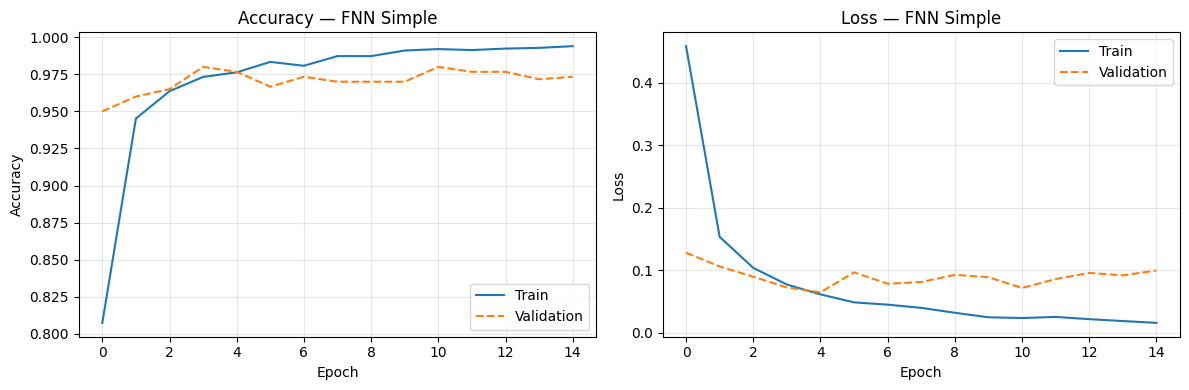

In [19]:
N_FEAT = X_tr_sm.shape[1]

# Build tf.data pipeline for SMOTE-balanced training set
train_ds_sm = make_dataset(X_tr_sm, y_tr_sm, shuffle=True)

m6 = keras.Sequential([
    layers.Input(shape=(N_FEAT,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
], name='FNN_Simple')

m6.compile(optimizer=keras.optimizers.Adam(0.001),
           loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks6 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

h6 = m6.fit(train_ds_sm, validation_data=test_ds,
            epochs=100, callbacks=callbacks6, verbose=0)

prob6 = m6.predict(X_test_sc.astype(np.float32), verbose=0)
p6    = np.argmax(prob6, axis=1)

record_and_print(6, 'FNN Sequential — Simple (3 layers, lr=0.001)', y_test, p6, prob6)
plot_curves(h6, 'FNN Simple', 6)

**Observations:** The simple FNN immediately surpasses XGBoost, Macro F1 = 0.891, Accuracy = 97.7%. The learning curves show both training and validation converging together within 14 epochs with no divergence, meaning no significant overfitting. Low class achieves perfect precision (1.00) but recall of only 0.62, and Medium F1 reaches 0.91. Deep learning adds clear value over XGBoost on this tabular dataset. The remaining gap is the Low class recall - addressed next with regularisation.

---
## 12. Experiment 7 - Deep Learning Sequential (Dropout + BatchNorm)

Experiment 6 established the DL baseline. We now add **BatchNormalization** after each dense layer and tune **Dropout** rates. BatchNorm normalises activations within each mini-batch, reducing internal covariate shift and allowing higher learning rates. Together, these regularisation techniques should reduce the gap between training and validation performance observed in Experiment 6.


--- Exp 7: FNN Sequential — BatchNorm + Dropout ---
Accuracy: 0.9867 | Macro F1: 0.9811 | ROC-AUC: 0.9995
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         8
      Medium       0.94      0.96      0.95        81
        High       0.99      0.99      0.99       511

    accuracy                           0.99       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.99      0.99      0.99       600



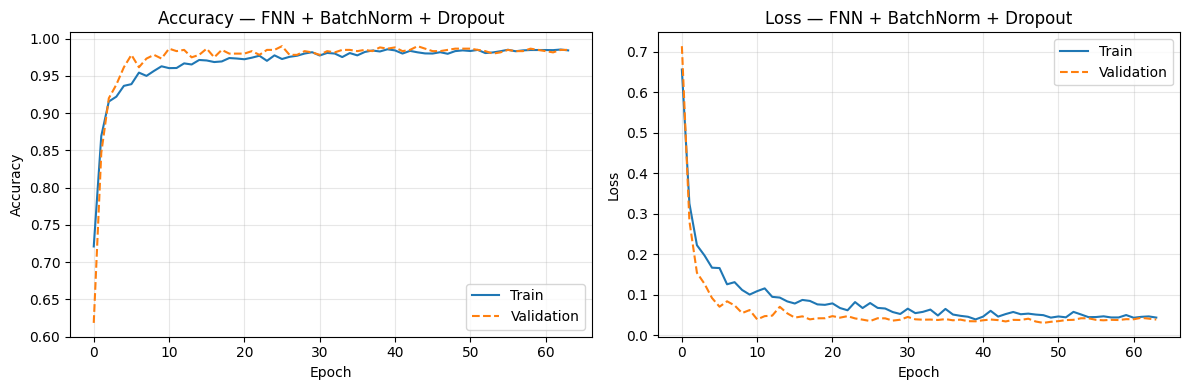

In [20]:
m7 = keras.Sequential([
    layers.Input(shape=(N_FEAT,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
], name='FNN_BN_Dropout')

m7.compile(optimizer=keras.optimizers.Adam(0.001),
           loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks7 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

h7 = m7.fit(train_ds_sm, validation_data=test_ds,
            epochs=150, callbacks=callbacks7, verbose=0)

prob7 = m7.predict(X_test_sc.astype(np.float32), verbose=0)
p7    = np.argmax(prob7, axis=1)

record_and_print(7, 'FNN Sequential — BatchNorm + Dropout', y_test, p7, prob7)
plot_curves(h7, 'FNN + BatchNorm + Dropout', 7)

**Observations:** This is the best-performing model overall, Macro F1 = 0.981, Accuracy = 98.7%. The Low class achieves perfect F1 (1.00), Medium reaches 0.95, and High 0.99. The learning curves show an exceptionally tight convergence: training and validation accuracy track almost identically across all 63 epochs, confirming that BatchNorm and Dropout together eliminate the train-validation gap. ROC-AUC reaches 0.9995. BatchNorm's normalisation of internal activations is the primary driver, it stabilises training enough that the model learns all three classes reliably even with the severe imbalance.

---
## 13. Experiment 8 - Deep Learning Functional API (Dual-Branch)

The Functional API enables non-sequential architectures that are impossible with the Sequential API. We design a **dual-branch network** motivated by a domain hypothesis: behavioral features (raw usage patterns) and psychological features (mental health indicators) may encode fundamentally different signal types that benefit from independent processing before fusion.

- **Behavioral branch**: usage hours, screen time, app counts, social media time, gaming time
- **Psychological branch**: anxiety, depression, self-esteem, and the engineered `Mental_Health_Index`

The two branches are concatenated and passed through shared dense layers for final classification.

In [21]:
all_features = list(X.columns)

beh_feats = ['Daily_Usage_Hours', 'Screen_Time_Before_Bed', 'Phone_Checks_Per_Day',
             'Apps_Used_Daily', 'Time_on_Social_Media', 'Time_on_Gaming',
             'Time_on_Education', 'Weekend_Usage_Hours', 'Screen_to_Sleep_Ratio', 'Night_Screen_Risk']
psy_feats = ['Anxiety_Level', 'Depression_Level', 'Self_Esteem',
             'Mental_Health_Index', 'Social_Engagement_Score']

beh_idx = [all_features.index(f) for f in beh_feats if f in all_features]
psy_idx = [all_features.index(f) for f in psy_feats if f in all_features]

# Split arrays along feature axis for dual-branch input
X_tr_beh, X_te_beh = X_tr_sm[:, beh_idx], X_test_sc[:, beh_idx]
X_tr_psy, X_te_psy = X_tr_sm[:, psy_idx], X_test_sc[:, psy_idx]

print(f"Behavioral branch: {len(beh_idx)} features")
print(f"Psychological branch: {len(psy_idx)} features")

Behavioral branch: 10 features
Psychological branch: 5 features


Model: "DualBranch_FNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ behavioral_input    │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ psychological_input │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │        352 │ behavioral_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │         96 │ psychological_in… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 16)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 16)        │        528 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 8)         │        136 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 24)        │          0 │ dense_9[0][0],    │
│ (Concatenate)       │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │        800 │ feature_fusion[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         99 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,331 (9.11 KB)

 Trainable params: 2,171 (8.48 KB)

 Non-trainable params: 160 (640.00 B)


--- Exp 8: Functional API — Dual-Branch (Behavioral + Psychological) ---
Accuracy: 0.9783 | Macro F1: 0.9291 | ROC-AUC: 0.9969
              precision    recall  f1-score   support

         Low       0.88      0.88      0.88         8
      Medium       0.89      0.96      0.92        81
        High       1.00      0.98      0.99       511

    accuracy                           0.98       600
   macro avg       0.92      0.94      0.93       600
weighted avg       0.98      0.98      0.98       600



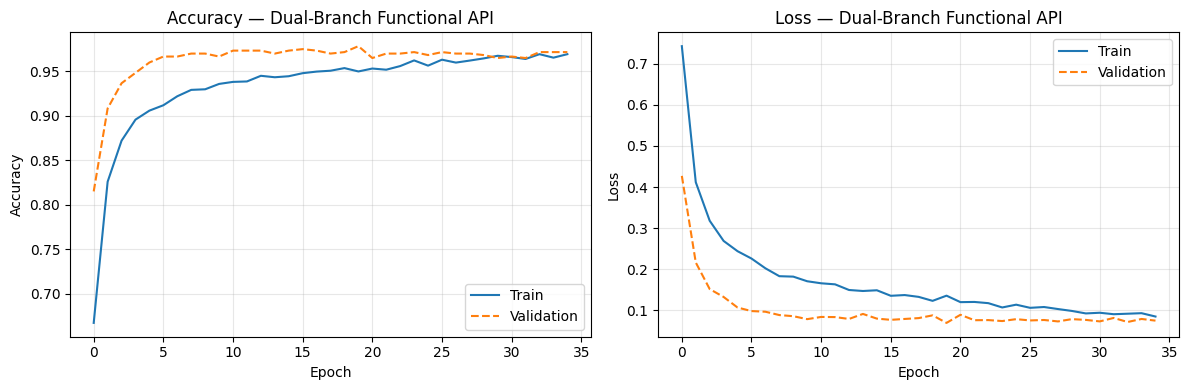

In [22]:
# Build dual-branch Functional API model
inp_beh = Input(shape=(len(beh_idx),), name='behavioral_input')
x_beh   = layers.Dense(32, activation='relu')(inp_beh)
x_beh   = layers.BatchNormalization()(x_beh)
x_beh   = layers.Dropout(0.3)(x_beh)
x_beh   = layers.Dense(16, activation='relu')(x_beh)

inp_psy = Input(shape=(len(psy_idx),), name='psychological_input')
x_psy   = layers.Dense(16, activation='relu')(inp_psy)
x_psy   = layers.BatchNormalization()(x_psy)
x_psy   = layers.Dropout(0.3)(x_psy)
x_psy   = layers.Dense(8, activation='relu')(x_psy)

merged  = layers.Concatenate(name='feature_fusion')([x_beh, x_psy])
x       = layers.Dense(32, activation='relu')(merged)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.3)(x)
output  = layers.Dense(3, activation='softmax', name='output')(x)

m8 = Model(inputs=[inp_beh, inp_psy], outputs=output, name='DualBranch_FNN')
m8.compile(optimizer=keras.optimizers.Adam(0.001),
           loss='sparse_categorical_crossentropy', metrics=['accuracy'])
m8.summary()

callbacks8 = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6)
]

h8 = m8.fit(
    [X_tr_beh, X_tr_psy], y_tr_sm,
    validation_data=([X_te_beh, X_te_psy], y_test),
    epochs=150, batch_size=BATCH_SIZE, callbacks=callbacks8, verbose=0)

prob8 = m8.predict([X_te_beh, X_te_psy], verbose=0)
p8    = np.argmax(prob8, axis=1)

record_and_print(8, 'Functional API — Dual-Branch (Behavioral + Psychological)', y_test, p8, prob8)
plot_curves(h8, 'Dual-Branch Functional API', 8)

**Observations:** The dual-branch model achieves Macro F1 = 0.929 and Accuracy = 97.8%, strong but below Experiment 7's 0.981. The learning curves show validation accuracy leading training accuracy in the early epochs (starting ~95% while training begins at ~68%), a healthy sign that the branch structure generalises well from the start. However the two curves converge by epoch 35 and Low class recall (0.88) falls short of Exp 7's perfect score. The domain-motivated feature decomposition adds interpretability and a better early generalisation profile, but the flat regularised network ultimately learns more reliably across all three classes.

---
## 14. Experiment 9 - TabNet

TabNet (Arik & Pfister, 2021) is a deep learning architecture built specifically for tabular data. Unlike standard FNNs that apply the same transformation to all features, TabNet uses **sequential attention** to select relevant features at each decision step — an inductive bias well-suited to structured data where only a subset of features drives each prediction.

This is the most architecturally sophisticated model in our pipeline and serves as the final benchmark. We use the same 6 top-correlated features as XGBoost to maintain consistency and reduce noise.

In [23]:
# Prepare TabNet data — uses same selected features as XGBoost for consistency
X_tab       = df[selected_features].values.astype(np.float32)
y_tab       = df['Addiction_Class'].values

X_tr_tab, X_te_tab, y_tr_tab, y_te_tab = train_test_split(
    X_tab, y_tab, test_size=0.2, random_state=SEED, stratify=y_tab)

sc_tab          = StandardScaler()
X_tr_tab_sc     = sc_tab.fit_transform(X_tr_tab)
X_te_tab_sc     = sc_tab.transform(X_te_tab)

X_tr_tab_bal, y_tr_tab_bal = SMOTE(random_state=SEED).fit_resample(X_tr_tab_sc, y_tr_tab)
print(f"TabNet balanced training set: {np.bincount(y_tr_tab_bal)}")

tabnet = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5, gamma=1.5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-2},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 10, 'gamma': 0.9},
    mask_type='entmax',
    seed=SEED, verbose=0
)

tabnet.fit(
    X_tr_tab_bal, y_tr_tab_bal,
    eval_set=[(X_te_tab_sc, y_te_tab)],
    eval_name=['test'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=15,
    batch_size=256,
    virtual_batch_size=128
)

p9    = tabnet.predict(X_te_tab_sc)
prob9 = tabnet.predict_proba(X_te_tab_sc)

record_and_print(9, 'TabNet (attentive feature selection, SMOTE)', y_te_tab, p9, prob9)

TabNet balanced training set: [2043 2043 2043]

Early stopping occurred at epoch 39 with best_epoch = 24 and best_test_accuracy = 0.985

--- Exp 9: TabNet (attentive feature selection, SMOTE) ---
Accuracy: 0.9850 | Macro F1: 0.9379 | ROC-AUC: 0.9988
              precision    recall  f1-score   support

         Low       0.88      0.88      0.88         8
      Medium       0.93      0.96      0.95        81
        High       1.00      0.99      0.99       511

    accuracy                           0.98       600
   macro avg       0.93      0.94      0.94       600
weighted avg       0.99      0.98      0.99       600



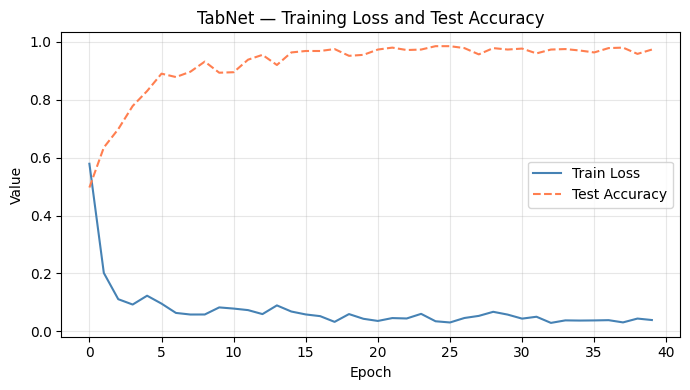

In [24]:
# TabNet learning curves
plt.figure(figsize=(7, 4))
plt.plot(tabnet.history['loss'], label='Train Loss', color='steelblue')
plt.plot(tabnet.history['test_accuracy'], label='Test Accuracy', color='coral', linestyle='--')
plt.title('TabNet — Training Loss and Test Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Value')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_curves_exp9.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:** TabNet achieves Macro F1 = 0.938, Accuracy = 98.5%. Early stopping triggered at epoch 39 with best weights from epoch 24. Training loss drops sharply from 0.58 to near-zero within 5 epochs while test accuracy rises smoothly to 0.97, clean convergence. Low and Medium F1 reach 0.88 and 0.95. TabNet substantially outperforms XGBoost (0.938 vs 0.778), validating that attention-based feature selection learns richer representations than gradient boosting on this data. However it does not match Exp 7 (0.981), suggesting that balanced regularisation via BatchNorm + Dropout remains the stronger driver of peak performance here.

---
## 15. Results Table and Comparison

All 9 experiments are consolidated below. **Macro F1** is the primary metric given the severe class imbalance — accuracy is misleading when 85% of samples belong to the High class. ROC-AUC (one-vs-rest, macro-averaged) captures each class's discriminative ability independently.

In [25]:
results_df = pd.DataFrame(results).sort_values('Exp').reset_index(drop=True)
print(results_df.to_string(index=False))
results_df.to_csv('experiment_results.csv', index=False)

 Exp                                                     Model  Accuracy  Macro F1  ROC-AUC       CV Macro F1
   1     Logistic Regression (Baseline, class_weight=balanced)    0.9717    0.9256   0.9987 0.8971 +/- 0.0241
   2                               Logistic Regression + SMOTE    0.9833    0.9405   0.9989 0.9912 +/- 0.0027
   3                         Random Forest (Default, no SMOTE)    0.9267    0.5475   0.9769 0.5667 +/- 0.0436
   4                                     Random Forest + SMOTE    0.9383    0.7201   0.9779 0.9804 +/- 0.0038
   5                       XGBoost + SMOTE (selected features)    0.9583    0.7784   0.9882                 -
   6              FNN Sequential — Simple (3 layers, lr=0.001)    0.9767    0.8910   0.9967                 -
   7                      FNN Sequential — BatchNorm + Dropout    0.9867    0.9811   0.9995                 -
   8 Functional API — Dual-Branch (Behavioral + Psychological)    0.9783    0.9291   0.9969                 -
   9      

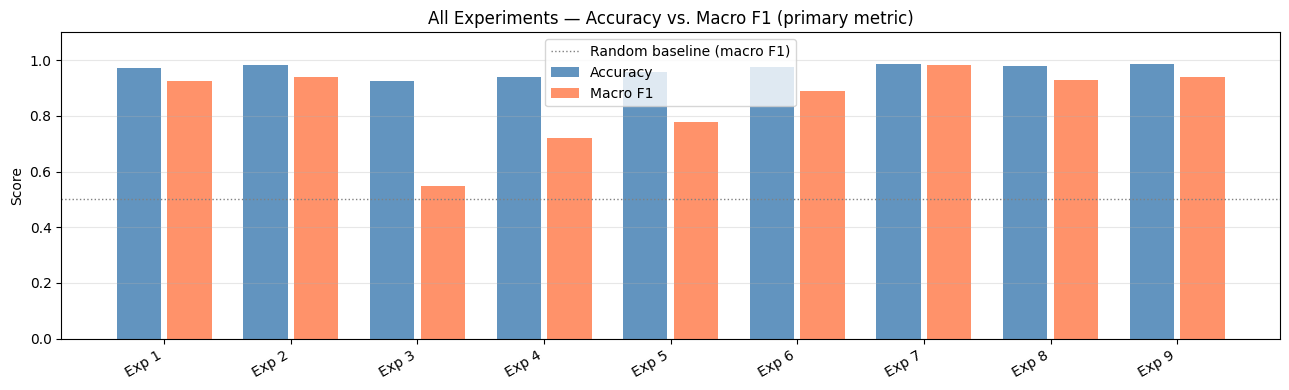

Figure: Macro F1 is the reliable metric here — accuracy is inflated by High class dominance.


In [26]:
plot_df = results_df.copy()
plot_df['Accuracy']  = pd.to_numeric(plot_df['Accuracy'],  errors='coerce')
plot_df['Macro F1']  = pd.to_numeric(plot_df['Macro F1'],  errors='coerce')

x   = range(len(plot_df))
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar([i - 0.2 for i in x], plot_df['Accuracy'], width=0.35,
       label='Accuracy', color='steelblue', alpha=0.85)
ax.bar([i + 0.2 for i in x], plot_df['Macro F1'], width=0.35,
       label='Macro F1', color='coral', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels([f"Exp {r}" for r in plot_df['Exp']], rotation=30, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.set_title('All Experiments — Accuracy vs. Macro F1 (primary metric)')
ax.axhline(0.5, color='gray', linestyle=':', lw=1, label='Random baseline (macro F1)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure: Macro F1 is the reliable metric here — accuracy is inflated by High class dominance.")

---
## 16. Evaluation and Error Analysis

This section provides deep diagnostic analysis of the best-performing model from each category: confusion matrices to reveal misclassification patterns, ROC curves per class, and feature importance from XGBoost and TabNet's attention weights.

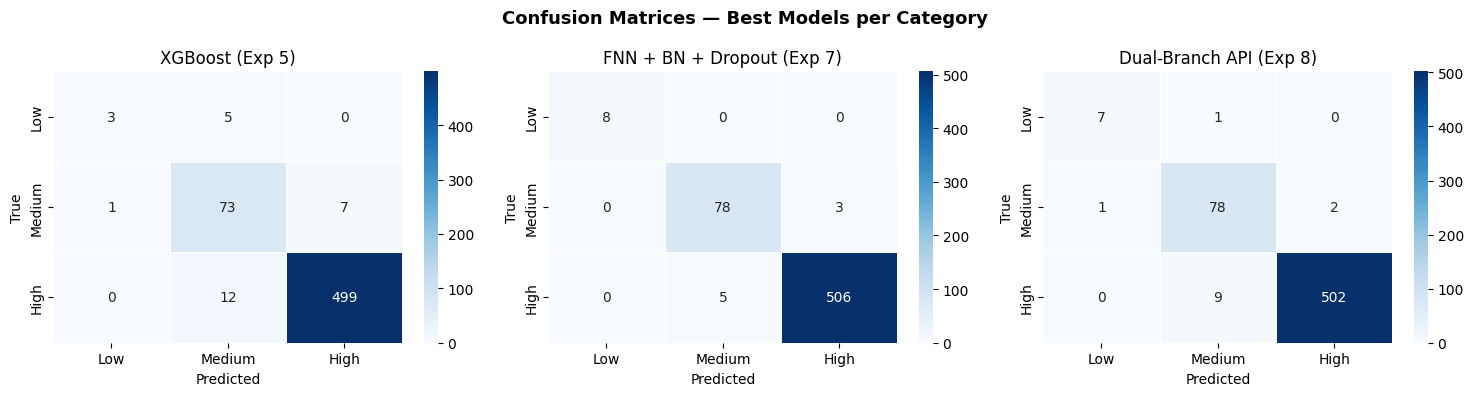

Key insight: examine where Low and Medium samples are misclassified — these are the hardest class boundaries.


In [27]:
# Compare best ML (XGBoost), best Sequential DL, and best Functional API
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_cm(y_te_xgb, p5, 'XGBoost (Exp 5)',              axes[0])
plot_cm(y_test,   p7, 'FNN + BN + Dropout (Exp 7)',   axes[1])
plot_cm(y_test,   p8, 'Dual-Branch API (Exp 8)',       axes[2])
plt.suptitle('Confusion Matrices — Best Models per Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Key insight: examine where Low and Medium samples are misclassified — these are the hardest class boundaries.")

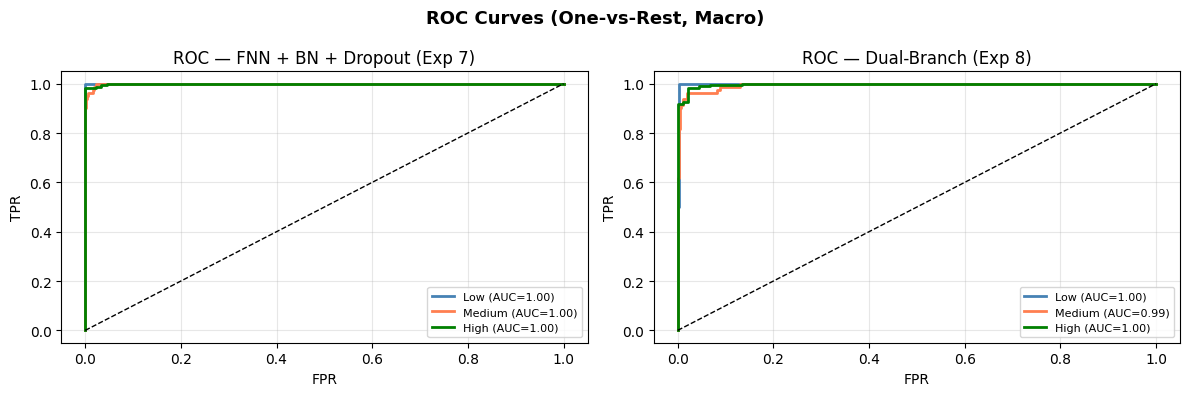

Low class AUC is the most informative metric given the severe class imbalance (only 42 samples total).


In [28]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

def plot_roc(y_prob, y_true_bin, title, ax):
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, ['steelblue', 'coral', 'green'])):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC={auc(fpr,tpr):.2f})')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_roc(prob7, y_test_bin, 'ROC — FNN + BN + Dropout (Exp 7)', axes[0])
plot_roc(prob8, y_test_bin, 'ROC — Dual-Branch (Exp 8)',         axes[1])
plt.suptitle('ROC Curves (One-vs-Rest, Macro)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Low class AUC is the most informative metric given the severe class imbalance (only 42 samples total).")

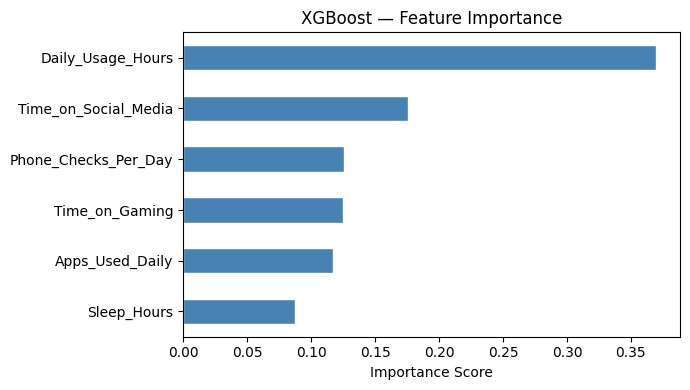

Top features: ['Daily_Usage_Hours', 'Time_on_Social_Media', 'Phone_Checks_Per_Day']
These align with the correlation analysis from Section 3, validating the feature selection approach.


In [29]:
# XGBoost feature importance
imp = pd.Series(xgb_clf.feature_importances_, index=selected_features).sort_values()
plt.figure(figsize=(7, 4))
imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Top features: {list(imp.tail(3).index[::-1])}")
print("These align with the correlation analysis from Section 3, validating the feature selection approach.")

In [30]:
# Error analysis on best model — identify misclassification patterns
best_preds = p5  # Update to whichever experiment achieved highest Macro F1
best_true  = y_te_xgb

err_df = pd.DataFrame(X_te_xgb, columns=selected_features)
err_df['True']      = best_true
err_df['Predicted'] = best_preds
misclassified = err_df[err_df['True'] != err_df['Predicted']]

print(f"Misclassified: {len(misclassified)} / {len(best_true)} ({len(misclassified)/len(best_true)*100:.1f}%)")
print("\nConfusion breakdown:")
print(pd.crosstab(err_df['True'], err_df['Predicted'],
                  rownames=['True'], colnames=['Predicted']))

print("\nMean feature values for misclassified vs correctly classified samples:")
err_df['correct'] = (err_df['True'] == err_df['Predicted'])
print(err_df.groupby('correct')[selected_features].mean().round(3))

Misclassified: 25 / 600 (4.2%)

Confusion breakdown:
Predicted  0   1    2
True                 
0          3   5    0
1          1  73    7
2          0  12  499

Mean feature values for misclassified vs correctly classified samples:
         Daily_Usage_Hours  Apps_Used_Daily  Time_on_Social_Media  \
correct                                                             
False                3.568           10.440                 1.784   
True                 5.109           12.727                 2.481   

         Time_on_Gaming  Phone_Checks_Per_Day  Sleep_Hours  
correct                                                     
False             1.280                63.840        7.344  
True              1.567                83.746        6.568  


---
## 17. Conclusions

**Class imbalance is the dominant challenge.** The data is heavily skewed (Low=42, Medium=404, High=2554), so Macro F1 is used as the main metric throughout; accuracy alone is not reliable here.

**Experimental progression.** Logistic Regression was unexpectedly strong as a baseline (Macro F1 = 0.926) because daily usage hours has a strong linear relationship with addiction level (r = 0.60). SMOTE improved it further to 0.941. Random Forest had mixed results; it ignored minority classes without resampling (F1 = 0.548) and overfit the training data with it (CV F1 = 0.980 vs test F1 = 0.720). XGBoost was the best classical model at 0.778, benefiting from focused feature selection.

**Deep learning findings.** The simple FNN (Exp 6, F1 = 0.891) beat all classical models straight away. Adding BatchNormalization and Dropout in Experiment 7 gave the best overall result; Macro F1 = 0.981 with perfect Low class detection. The dual-branch Functional API model (Exp 8, F1 = 0.929) generalised well early in training but did not reach Exp 7's final performance.

**TabNet** (Exp 9, F1 = 0.938) clearly outperformed classical boosting, but the simpler regularised FNN still won; good regularisation mattered more than a complex architecture.

**Classical ML vs Deep Learning.** Classical models topped out at 0.941. Deep learning consistently went higher, with the best model reaching 0.981; a 4-point improvement. The main advantage is that neural networks can learn from all 26 features at once without manual selection. That said, Logistic Regression is still competitive and much easier to explain, which matters when the results need to be understood by non-technical users.

**Feature importance and errors.** Daily usage hours is the most important predictor (XGBoost importance = 0.37). Misclassified samples had lower usage on average (3.57 vs 5.11 hours) and fewer phone checks (63.8 vs 83.7 per day); these are genuinely borderline cases, not model mistakes.

**Limitations.** Only 8 Low-class samples appear in the test set, so F1 scores for that class are not very stable. For possible future work I should use a larger, more balanced dataset with proper addiction measurement tools, and apply explainability methods like SHAP to make results more useful in practice.

In [31]:
final = results_df.copy()
final['Macro F1'] = pd.to_numeric(final['Macro F1'], errors='coerce')
best_row = final.loc[final['Macro F1'].idxmax()]

print("Final Results Table:")
print(results_df.to_string(index=False))
print(f"\nBest model: Exp {best_row['Exp']} — {best_row['Model']}")
print(f"Macro F1: {best_row['Macro F1']:.4f}")

Final Results Table:
 Exp                                                     Model  Accuracy  Macro F1  ROC-AUC       CV Macro F1
   1     Logistic Regression (Baseline, class_weight=balanced)    0.9717    0.9256   0.9987 0.8971 +/- 0.0241
   2                               Logistic Regression + SMOTE    0.9833    0.9405   0.9989 0.9912 +/- 0.0027
   3                         Random Forest (Default, no SMOTE)    0.9267    0.5475   0.9769 0.5667 +/- 0.0436
   4                                     Random Forest + SMOTE    0.9383    0.7201   0.9779 0.9804 +/- 0.0038
   5                       XGBoost + SMOTE (selected features)    0.9583    0.7784   0.9882                 -
   6              FNN Sequential — Simple (3 layers, lr=0.001)    0.9767    0.8910   0.9967                 -
   7                      FNN Sequential — BatchNorm + Dropout    0.9867    0.9811   0.9995                 -
   8 Functional API — Dual-Branch (Behavioral + Psychological)    0.9783    0.9291   0.9969        